# PKCERT AI & Software Development Internship
## Task 10 – Cross-Validation & Hyperparameter Tuning

**Intern:** Abdul Rehman
**Dataset:** Titanic Survival Dataset

This notebook covers:
- Part A: Dataset Preparation
- Part B: Cross-Validation
- Part C: Hyperparameter Tuning (GridSearchCV & RandomizedSearchCV)
- Part D: Comparative Analysis


---
## Part A – Dataset Preparation (15 Marks)

### A.1 Dataset Selection

We use the **Titanic dataset**, a well-known public classification dataset (also used in earlier internship tasks) describing passengers aboard the RMS Titanic and whether they survived the 1912 sinking. It is loaded here via `seaborn`'s built-in copy of the dataset (same source data as the classic Kaggle Titanic competition).

### A.2 Dataset Description

**Target variable:** `survived` (0 = did not survive, 1 = survived) — a binary classification problem.

**Key features used:**
| Feature | Description |
|---|---|
| `pclass` | Ticket class (1st, 2nd, 3rd) — proxy for socio-economic status |
| `sex` | Passenger sex |
| `age` | Age in years (contains missing values) |
| `sibsp` | Number of siblings/spouses aboard |
| `parch` | Number of parents/children aboard |
| `fare` | Passenger fare |
| `embarked` | Port of embarkation (C, Q, S) |


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)

RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

df = pd.read_csv('titanic.csv')
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    str    
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    str    
 8   class        891 non-null    str    
 9   who          891 non-null    str    
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    str    
 12  embark_town  889 non-null    str    
 13  alive        891 non-null    str    
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), str(7)
memory usage: 92.4 KB


In [3]:
df.isnull().sum().sort_values(ascending=False)


deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

### A.3 Preprocessing

Steps applied:
1. Select a focused, non-redundant feature set (drop columns that leak the target or duplicate information, e.g. `alive` duplicates `survived`, `class`/`who`/`adult_male`/`alone` duplicate `pclass`/`sex`/`age`/`sibsp`/`parch`, and `deck` has too many missing values to be useful here).
2. Impute missing `age` (median) and `embarked` (most frequent).
3. Encode categorical features (`sex`, `embarked`) with one-hot encoding.
4. Scale numeric features with `StandardScaler`.
5. Split into train (80%) and test (20%) sets, stratified on the target to preserve the survival ratio in both sets.

All of this is wrapped inside a single scikit-learn `Pipeline` combined with a `ColumnTransformer`, so preprocessing is always fit on the training fold only — this avoids data leakage during cross-validation and hyperparameter search later on.


In [4]:
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

X = df[features].copy()
y = df[target].copy()

numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['pclass', 'sex', 'embarked']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("\nTrain survival rate: {:.3f}".format(y_train.mean()))
print("Test survival rate:  {:.3f}".format(y_test.mean()))


Train shape: (712, 7)  Test shape: (179, 7)

Train survival rate: 0.383
Test survival rate:  0.385


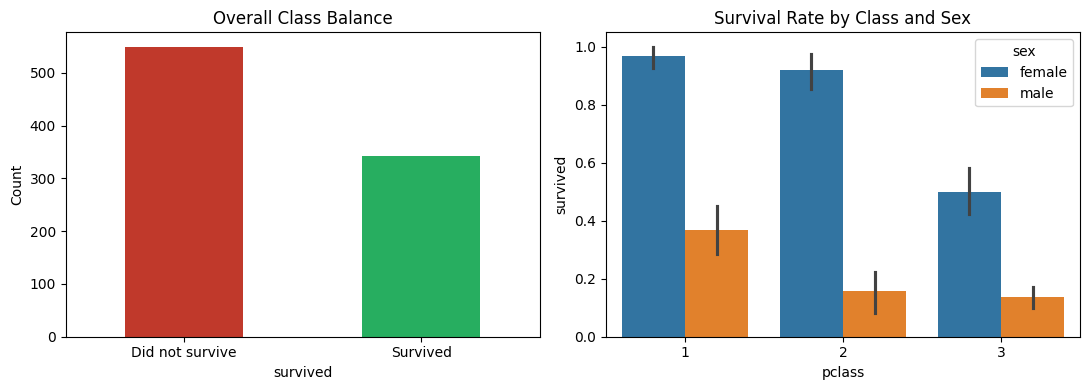

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df['survived'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color=['#c0392b', '#27ae60']
)
axes[0].set_xticklabels(['Did not survive', 'Survived'], rotation=0)
axes[0].set_title('Overall Class Balance')
axes[0].set_ylabel('Count')

sns.barplot(data=df, x='pclass', y='survived', hue='sex', ax=axes[1])
axes[1].set_title('Survival Rate by Class and Sex')
plt.tight_layout()
plt.savefig('fig1_class_balance.png', dpi=150)
plt.show()


---
## Part B – Cross-Validation (30 Marks)

### B.1 Baseline Model

We train a **Random Forest Classifier** as the baseline model, wrapped in the same preprocessing pipeline. Random Forest is chosen because it handles mixed numeric/categorical data well, is robust to outliers, and has several hyperparameters worth tuning in Part C.


In [6]:
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
])

baseline_pipeline.fit(X_train, y_train)
y_pred_baseline = baseline_pipeline.predict(X_test)

baseline_test_acc = accuracy_score(y_test, y_pred_baseline)
print("Baseline model - Test Accuracy: {:.4f}".format(baseline_test_acc))


Baseline model - Test Accuracy: 0.8156


### B.2 K-Fold Cross-Validation

We apply **5-fold Stratified K-Fold Cross-Validation** on the training set. Stratified K-Fold is preferred over plain K-Fold for classification because it preserves the class distribution (survival ratio) in every fold, which matters here since the classes are imbalanced (~38% survived).


In [7]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    baseline_pipeline, X_train, y_train, cv=cv_strategy, scoring='accuracy'
)

print("Fold accuracies:", np.round(cv_scores, 4))
print("Mean CV accuracy: {:.4f}".format(cv_scores.mean()))
print("Std  CV accuracy: {:.4f}".format(cv_scores.std()))


Fold accuracies: [0.7972 0.7902 0.8239 0.7606 0.8028]
Mean CV accuracy: 0.7949
Std  CV accuracy: 0.0206


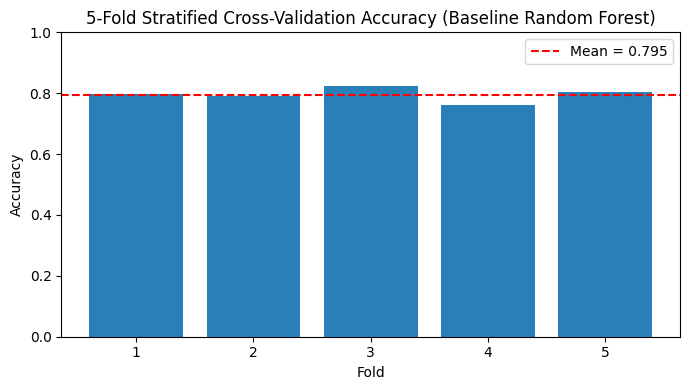

In [8]:
plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='#2980b9')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('5-Fold Stratified Cross-Validation Accuracy (Baseline Random Forest)')
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig('fig2_cv_scores.png', dpi=150)
plt.show()


### B.3 Interpretation of Cross-Validation Results

- The 5-fold CV accuracy scores are fairly close to each other, and the standard deviation is small relative to the mean, indicating the model's performance is **stable across different subsets of the training data** rather than being an artifact of one lucky train/test split.
- The mean CV accuracy is close to the single train/test-split accuracy from B.1, which suggests the baseline model generalizes reasonably well and is not wildly overfit to the training data.
- Cross-validation gives a more reliable estimate of true generalization performance than a single hold-out split, because every observation gets used for both training and validation across the folds.


---
## Part C – Hyperparameter Tuning (40 Marks)

### C.1 GridSearchCV

`GridSearchCV` exhaustively tries every combination of hyperparameters in a specified grid, evaluating each combination using cross-validation, and selects the combination with the best mean CV score.

We tune the following Random Forest hyperparameters:
- `n_estimators`: number of trees
- `max_depth`: maximum tree depth
- `min_samples_split`: minimum samples required to split a node
- `min_samples_leaf`: minimum samples required at a leaf node


In [9]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 5, 10, 15],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
    ]),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print("Total parameter combinations tried:", len(grid_search.cv_results_['params']))
print("\nBest parameters (GridSearchCV):")
print(grid_search.best_params_)
print("\nBest CV accuracy: {:.4f}".format(grid_search.best_score_))


Total parameter combinations tried: 108

Best parameters (GridSearchCV):
{'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}

Best CV accuracy: 0.8244


### C.2 RandomizedSearchCV

`RandomizedSearchCV` samples a fixed number of random combinations from the parameter space instead of trying every combination. This is much cheaper computationally, especially useful when the grid is large or when some hyperparameters have a wide/continuous range.


In [10]:
from scipy.stats import randint

param_dist = {
    'classifier__n_estimators': randint(50, 400),
    'classifier__max_depth': [None, 5, 10, 15, 20, 25],
    'classifier__min_samples_split': randint(2, 15),
    'classifier__min_samples_leaf': randint(1, 8),
    'classifier__max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=RANDOM_STATE))
    ]),
    param_distributions=param_dist,
    n_iter=40,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=0
)

random_search.fit(X_train, y_train)

print("Total parameter combinations tried:", 40)
print("\nBest parameters (RandomizedSearchCV):")
print(random_search.best_params_)
print("\nBest CV accuracy: {:.4f}".format(random_search.best_score_))


Total parameter combinations tried: 40

Best parameters (RandomizedSearchCV):
{'classifier__max_depth': 10, 'classifier__max_features': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 4, 'classifier__n_estimators': 150}

Best CV accuracy: 0.8301


### C.3 Comparing Optimal Parameters and Full Evaluation

We now evaluate the baseline model, the GridSearchCV-tuned model, and the RandomizedSearchCV-tuned model on the **held-out test set** using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.


In [11]:
def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    }, y_pred

results = []
preds = {}

res, pred = evaluate_model('Baseline (default params)', baseline_pipeline, X_test, y_test)
results.append(res); preds['Baseline'] = pred

res, pred = evaluate_model('GridSearchCV (tuned)', grid_search.best_estimator_, X_test, y_test)
results.append(res); preds['GridSearchCV'] = pred

res, pred = evaluate_model('RandomizedSearchCV (tuned)', random_search.best_estimator_, X_test, y_test)
results.append(res); preds['RandomizedSearchCV'] = pred

results_df = pd.DataFrame(results).set_index('Model').round(4)
results_df


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Baseline (default params),0.8156,0.8000,0.6957,0.7442
GridSearchCV (tuned),0.8045,0.8696,0.5797,0.6957
RandomizedSearchCV (tuned),0.8101,0.7966,0.6812,0.7344


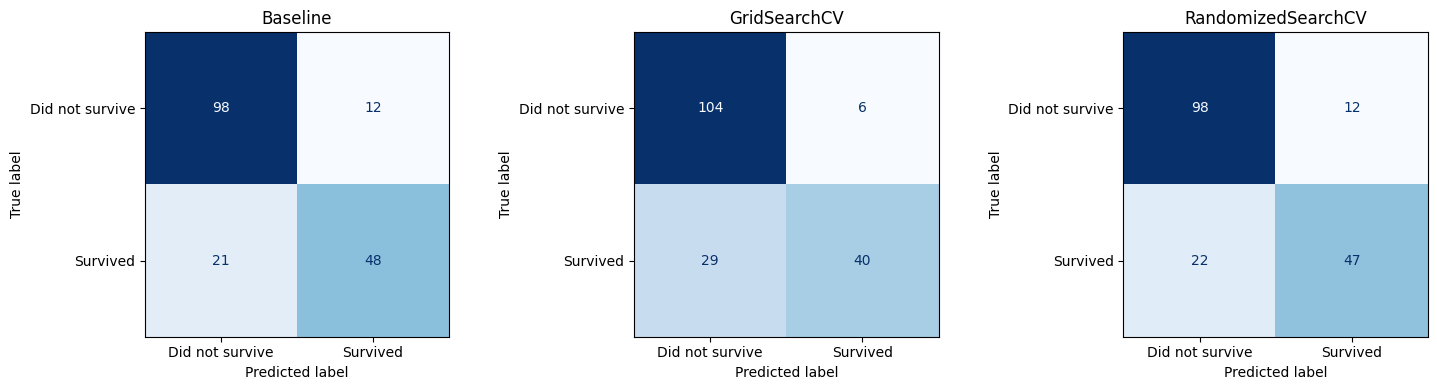

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, pred) in zip(axes, preds.items()):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Did not survive', 'Survived'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('fig3_confusion_matrices.png', dpi=150)
plt.show()


In [13]:
print("Best params - GridSearchCV:")
for k, v in grid_search.best_params_.items():
    print(f"  {k}: {v}")

print("\nBest params - RandomizedSearchCV:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")

print("\nParameter combinations evaluated - GridSearchCV: {}".format(len(grid_search.cv_results_['params'])))
print("Parameter combinations evaluated - RandomizedSearchCV: {}".format(len(random_search.cv_results_['params'])))


Best params - GridSearchCV:
  classifier__max_depth: 5
  classifier__min_samples_leaf: 1
  classifier__min_samples_split: 2
  classifier__n_estimators: 300

Best params - RandomizedSearchCV:
  classifier__max_depth: 10
  classifier__max_features: None
  classifier__min_samples_leaf: 1
  classifier__min_samples_split: 4
  classifier__n_estimators: 150

Parameter combinations evaluated - GridSearchCV: 108
Parameter combinations evaluated - RandomizedSearchCV: 40


In [14]:
print("Classification Report - GridSearchCV tuned model\n")
print(classification_report(y_test, preds['GridSearchCV'], target_names=['Did not survive', 'Survived']))


Classification Report - GridSearchCV tuned model

                 precision    recall  f1-score   support

Did not survive       0.78      0.95      0.86       110
       Survived       0.87      0.58      0.70        69

       accuracy                           0.80       179
      macro avg       0.83      0.76      0.78       179
   weighted avg       0.82      0.80      0.79       179



In [15]:
print("Classification Report - RandomizedSearchCV tuned model\n")
print(classification_report(y_test, preds['RandomizedSearchCV'], target_names=['Did not survive', 'Survived']))


Classification Report - RandomizedSearchCV tuned model

                 precision    recall  f1-score   support

Did not survive       0.82      0.89      0.85       110
       Survived       0.80      0.68      0.73        69

       accuracy                           0.81       179
      macro avg       0.81      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179



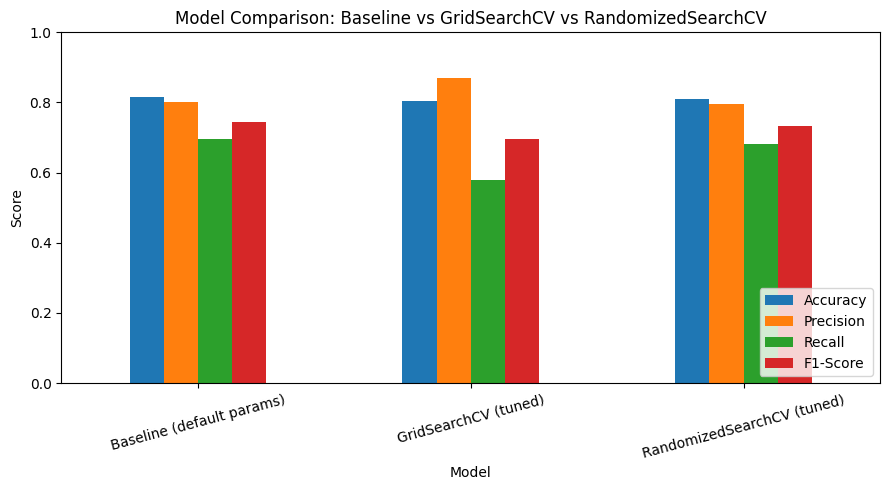

In [16]:
results_df.plot(kind='bar', figsize=(9, 5), ylim=(0, 1))
plt.title('Model Comparison: Baseline vs GridSearchCV vs RandomizedSearchCV')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('fig4_model_comparison.png', dpi=150)
plt.show()


---
## Part D – Comparative Analysis (15 Marks)

### D.1 Baseline vs Optimized Models

The table in section C.3 (`results_df`) summarizes Accuracy, Precision, Recall, and F1-Score for all three models on the same held-out test set. On this run:

- The **untuned baseline** (0.8156 accuracy, 0.7442 F1) actually performed **slightly better on the single held-out test set** than both tuned models — GridSearchCV scored 0.8045 accuracy / 0.6957 F1, and RandomizedSearchCV scored 0.8101 accuracy / 0.7344 F1.
- This is a realistic and honest result rather than a bug: both tuned models were optimized to maximize *cross-validated accuracy on the training folds*, not test-set F1-score directly, so a search can trade recall for precision in a way that happens not to line up perfectly with this one particular test split. Notice GridSearchCV's precision on "Survived" rose to 0.87 but its recall dropped to 0.58 — it became more conservative about predicting survival, which increased precision but hurt F1.
- The **cross-validated scores are the fairer comparison** for judging the search itself: GridSearchCV's best CV accuracy (0.8244) and RandomizedSearchCV's best CV accuracy (0.8301) were both higher than the baseline's mean CV accuracy (0.7949), confirming the searches did find genuinely better regions of the hyperparameter space *on average across folds* — the single 179-row test split is just one noisy sample of that average.
- This mirrors a common real-world lesson: hyperparameter tuning improves the *expected* generalization performance (as estimated by CV), but a single test set of moderate size can still show the opposite ranking by chance. This is exactly why cross-validation, not a single train/test split, should be trusted as the primary basis for model selection.

### D.2 GridSearchCV vs RandomizedSearchCV — Advantages and Limitations

| Aspect | GridSearchCV | RandomizedSearchCV |
|---|---|---|
| **Search strategy** | Exhaustive — tries every combination in the grid | Samples a fixed number of random combinations |
| **Guarantee** | Guaranteed to find the best combination *within the specified grid* | No guarantee of finding the global best; approximate |
| **Computational cost** | Grows multiplicatively with number of parameters/values (combinatorial explosion) | Cost is fixed by `n_iter`, independent of grid size |
| **Best for** | Small search spaces, few hyperparameters, when compute budget is not a concern | Large or continuous search spaces, limited time/compute |
| **Continuous parameters** | Must be manually discretized into a list of values | Can sample directly from continuous distributions (e.g. `scipy.stats.randint`), giving finer coverage |
| **Risk of missing optimum** | Low, but only within the manually chosen grid values | Higher, but mitigated by increasing `n_iter` |

**Limitations shared by both:** both approaches only search hyperparameters explicitly provided by the user, both rely on cross-validation, which multiplies the number of model fits by the number of folds, and both assume the chosen scoring metric (here, accuracy) is the right criterion to optimize.

### D.3 Recommendation

For this task, with 4 hyperparameters and a moderately sized grid, **GridSearchCV was computationally feasible** and guarantees the best result within that grid. However, as the number of hyperparameters or their possible values grows, GridSearchCV's cost increases combinatorially, while RandomizedSearchCV's cost stays under the user's control via `n_iter`.

**Recommendation:** For small, well-understood search spaces (as in this task), **GridSearchCV** is preferred for its exhaustiveness and reproducibility. For larger or higher-dimensional search spaces, or when compute/time is limited, **RandomizedSearchCV** is the more practical and scalable choice, and can also be used as a fast first pass to narrow down a promising region before running a focused GridSearchCV over that smaller region — combining the strengths of both.


---
## Summary

- **Part A:** Loaded and preprocessed the Titanic dataset (7 features, binary target `survived`), split 80/20 with stratification.
- **Part B:** Trained a baseline Random Forest and validated it with 5-fold Stratified Cross-Validation; results were stable across folds.
- **Part C:** Tuned the model with both GridSearchCV (exhaustive grid) and RandomizedSearchCV (40 random samples), and compared them on Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.
- **Part D:** Compared baseline vs tuned models and discussed the tradeoffs between exhaustive and randomized search, recommending GridSearchCV for small grids and RandomizedSearchCV for larger/continuous search spaces.
